# Projeto Rotatividade Funcionários

## Objetivo:

Prever se o funcionário pedirá demissão da empresa

### Dicionário de dados: Descrição a que se refere cada variável do conjunto de dados

<p><p><p>
<br><b>Employee ID</b> - Um identificador exclusivo atribuído a cada funcionário
<br><b>Age</b> - A idade do funcionário, variando de 18 a 60 anos.
<br><b>Gender</b> - O gênero do funcionário
<br><b>Years at Company</b> - O tempo que o funcionário está na empresa
<br><b>Job Role</b> - O departamento ou função em que o funcionário trabalha, codificado em categorias como Finanças, Saúde, <br>Tecnologia, Educação e Mídia.
<br><b>Monthly Income</b> - O salário mensal do funcionário, em dólares.
<br><b>Work-Life Balance</b> - O equilíbrio percebido pelo funcionário entre trabalho e vida pessoal (Ruim, Abaixo da média, Bom, Excelente)
<br><b>Job Satisfaction</b> - A satisfação do funcionário com seu trabalho: (Muito baixo, Baixo, Médio, Alto)
<br><b>Performance Rating</b> - A classificação de desempenho do funcionário: (Baixo, Abaixo da média, Médio, Alto)
<br><b>Number of Promotions</b> - O número total de promoções que o funcionário recebeu.
<br><b>Overtime</b> - Se o funcionário faz hora extra
<br><b>Distance from Home</b> - A distância entre a casa do funcionário e o local de trabalho, em milhas.
<br><b>Education Level</b> - O nível de educação mais alto atingido pelo funcionário: (Ensino médio, diploma de associado, bacharelado, mestrado, doutorado)
<br><b>Marital Status</b> - O estado civil do funcionário: (Divorciado, casado, solteiro)
<br><b>Number of Dependents</b> - Número de dependentes do funcionário
<br><b>Job Level</b> - O nível do cargo do funcionário: (Iniciante, Médio, Sênior)
<br><b>Company Size</b> - O tamanho da empresa para a qual o funcionário trabalha: (Pequeno, Médio, Grande)
<br><b>Company Tenure</b> - O número total de anos em que o funcionário trabalha no setor.
<br><b>Remote Work</b> - Se o funcionário trabalha remotamente: (Sim ou Não)
<br><b>Leadership Opportunities</b> - Se o funcionário tem oportunidades de liderança: (Sim ou Não)
<br><b>Innovation Opportunities</b> - Se o funcionário tem oportunidades de inovação: (Sim ou Não)
<br><b>Company Reputation</b> - A percepção do funcionário sobre a reputação da empresa: (Muito ruim, Ruim, Bom, Excelente)
<br><b>Employee Recognition</b> - O nível de reconhecimento que o funcionário recebe: (Muito baixo, Baixo, Médio, Alto)
<br><b>Attrition</b> - Se o funcionário saiu da empresa, codificado como 0 (permaneceu) e 1 (Saiu).

In [57]:
## Carregando os pacotes que serão utilizados
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import numpy as np
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from category_encoders.one_hot import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

from imblearn import under_sampling, over_sampling
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, accuracy_score
from imblearn.under_sampling import RandomUnderSampler
from config import data

In [58]:
# Configuração básica do arquivo

warnings.filterwarnings("ignore") 
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [59]:
# Importando arquivo

df = pd.read_csv(data/'dados_historicos.csv')

### Analise Exploratória

In [60]:
# Visualização dos dados

df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,Education Level,Marital Status,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390.0,Excellent,Medium,Average,2,No,22,Associate Degree,Married,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534.0,Poor,High,Low,3,No,21,Master’s Degree,Divorced,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159.0,Good,High,Low,0,No,11,Bachelor’s Degree,Married,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,NaN,Good,High,High,1,No,27,High School,Single,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821.0,Fair,Very High,Average,0,Yes,71,High School,Divorced,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [61]:
# Renomeando as colunas 

df.columns = ['ID_Funcionario', 
              'Idade', 
              'Genero', 
              'Anos_Empresa', 
              'Funcao', 
              'Salario_Mensal',
              'Equilibrio_Vida',
              'Satisfacao',
              'Desempenho',
              'Qtd_Promocoes',
              'Hora_Extra',
              'Distancia_Casa',
              'Escolaridade',
              'Estado_Civil',
              'Qtd_Dependentes',
              'Cargo',
              'Tamanho_Empresa',
              'Qtd_Anos_Trabalho',
              'Trabalho_Remoto',
              'Oportunidade_Lideranca',
              'Oportunidade_Inovacao',
              'Reputacao_Empresa',
              'Reconhecimento',
              'Situacao']

In [62]:
# Tamanho do DF

df.shape

(59598, 24)

In [63]:
# Informações dos tipos de variáveis

df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Funcionario          59598 non-null  int64  
 1   Idade                   59598 non-null  int64  
 2   Genero                  59598 non-null  str    
 3   Anos_Empresa            59598 non-null  int64  
 4   Funcao                  59598 non-null  str    
 5   Salario_Mensal          59591 non-null  float64
 6   Equilibrio_Vida         59598 non-null  str    
 7   Satisfacao              59598 non-null  str    
 8   Desempenho              59598 non-null  str    
 9   Qtd_Promocoes           59598 non-null  int64  
 10  Hora_Extra              59598 non-null  str    
 11  Distancia_Casa          59598 non-null  int64  
 12  Escolaridade            59598 non-null  str    
 13  Estado_Civil            59598 non-null  str    
 14  Qtd_Dependentes         59598 non-null  int64  
 

In [64]:
# Verificando os nulos

df.isnull().sum()

ID_Funcionario            0
Idade                     0
Genero                    0
Anos_Empresa              0
Funcao                    0
Salario_Mensal            7
Equilibrio_Vida           0
Satisfacao                0
Desempenho                0
Qtd_Promocoes             0
Hora_Extra                0
Distancia_Casa            0
Escolaridade              0
Estado_Civil              0
Qtd_Dependentes           0
Cargo                     0
Tamanho_Empresa           0
Qtd_Anos_Trabalho         0
Trabalho_Remoto           0
Oportunidade_Lideranca    0
Oportunidade_Inovacao     0
Reputacao_Empresa         0
Reconhecimento            0
Situacao                  0
dtype: int64

In [65]:
# Validando os valores únicos

df.nunique()

ID_Funcionario            59598
Idade                        42
Genero                        2
Anos_Empresa                 51
Funcao                        5
Salario_Mensal             9569
Equilibrio_Vida               4
Satisfacao                    4
Desempenho                    4
Qtd_Promocoes                 5
Hora_Extra                    2
Distancia_Casa               99
Escolaridade                  5
Estado_Civil                  3
Qtd_Dependentes               7
Cargo                         3
Tamanho_Empresa               3
Qtd_Anos_Trabalho           127
Trabalho_Remoto               2
Oportunidade_Lideranca        2
Oportunidade_Inovacao         2
Reputacao_Empresa             4
Reconhecimento                4
Situacao                      2
dtype: int64

In [66]:
# visualizando a quantidade mínima e máxima da variavel IDADE

print('Menor Idade:', df['Idade'].min())
print('Maior Idade:', df['Idade'].max())

Menor Idade: 18
Maior Idade: 59


In [67]:
# visualizando a quantidade mínima e máxima da variavel Anos_Empresa
# Precisaremos fazer algum tipo de tratamento nessa variável, pois há um número muito elevado de anos na empresa

print('Menor Tempo:', df['Anos_Empresa'].min())
print('Maior Tempo:', df['Anos_Empresa'].max())

Menor Tempo: 1
Maior Tempo: 51


In [68]:
# visualizando a quantidade mínima e máxima da variavel QTD_ANOS_TRABALHO
# Precisaremos fazer algum tipo de tratamento nessa variável, pois há um número muito elevado de anos de trabalho

print('Menor Tempo:', df['Qtd_Anos_Trabalho'].min())
print('Maior Tempo:', df['Qtd_Anos_Trabalho'].max())

Menor Tempo: 2
Maior Tempo: 128


In [69]:
# visualizando a quantidade mínima e máxima da variavel DISTANCIA_CASA

print('Menor Distância:', df['Distancia_Casa'].min())
print('Maior Distância:', df['Distancia_Casa'].max())

Menor Distância: 1
Maior Distância: 99


In [70]:
# visualizando a quantidade mínima e máxima da variavel QTD_DEPENDENTES

print('Menor Quantidade:', df['Qtd_Dependentes'].min())
print('Maior Quantidade:', df['Qtd_Dependentes'].max())

Menor Quantidade: 0
Maior Quantidade: 6


In [71]:
# visualizando a quantidade mínima e máxima da variavel SALÁRIO_MENSAL

print('Menor Salario:', df['Salario_Mensal'].min())
print('Maior Salario:', df['Salario_Mensal'].max())

Menor Salario: 1316.0
Maior Salario: 16149.0


In [72]:
# Medidas estatísticas básicas

df.describe()

,ID_Funcionario,Idade,Anos_Empresa,Salario_Mensal,Qtd_Promocoes,Distancia_Casa,Qtd_Dependentes,Qtd_Anos_Trabalho
count,59598.000000,59598.000000,59598.000000,59591.000000,59598.000000,59598.000000,59598.000000,59598.000000
mean,37227.118729,38.565875,15.753901,7302.346327,0.832578,50.007651,1.648075,55.758415
std,21519.150028,12.079673,11.245981,2151.445271,0.994991,28.466459,1.555689,25.411090
min,1.000000,18.000000,1.000000,1316.000000,0.000000,1.000000,0.000000,2.000000
25%,18580.250000,28.000000,7.000000,5658.000000,0.000000,25.000000,0.000000,36.000000
50%,37209.500000,39.000000,13.000000,7354.000000,1.000000,50.000000,1.000000,56.000000
75%,55876.750000,49.000000,23.000000,8880.000000,2.000000,75.000000,3.000000,76.000000
max,74498.000000,59.000000,51.000000,16149.000000,4.000000,99.000000,6.000000,128.000000


In [73]:
# Verificando os casos que a qtd_anos_trabalho é superior a idade do funcionário. 
# Será necessário corrigir para os casos que isso ocorre

df[df['Qtd_Anos_Trabalho'] > df['Idade']].shape

(42283, 24)

In [74]:
# Verificando se temos casos de anos_empresa > idade do funcionario

df[df['Anos_Empresa'] > df['Idade']].shape

(0, 24)

In [75]:
# Verificando se tem algum registro de funcionário com entrada na empresa abaixo de 18 anos. 

df[(df['Idade'] - df['Anos_Empresa']) < 18].shape

(23797, 24)

In [76]:
# Carregar variaveis númericas para plot
variaveis_numericas = []
for i in df.columns[0:24].tolist():
        if df.dtypes[i] == 'int64' or df.dtypes[i] == 'float64':                        
            variaveis_numericas.append(i)  

In [77]:
# Carregar variaveis categoricas para plot
variaveis_categoricas = []
for i in df.columns[0:24].tolist():
        if df.dtypes[i] == 'object' or df.dtypes[i] == 'category' or df.dtypes[i] == 'str':                        
            variaveis_categoricas.append(i)  

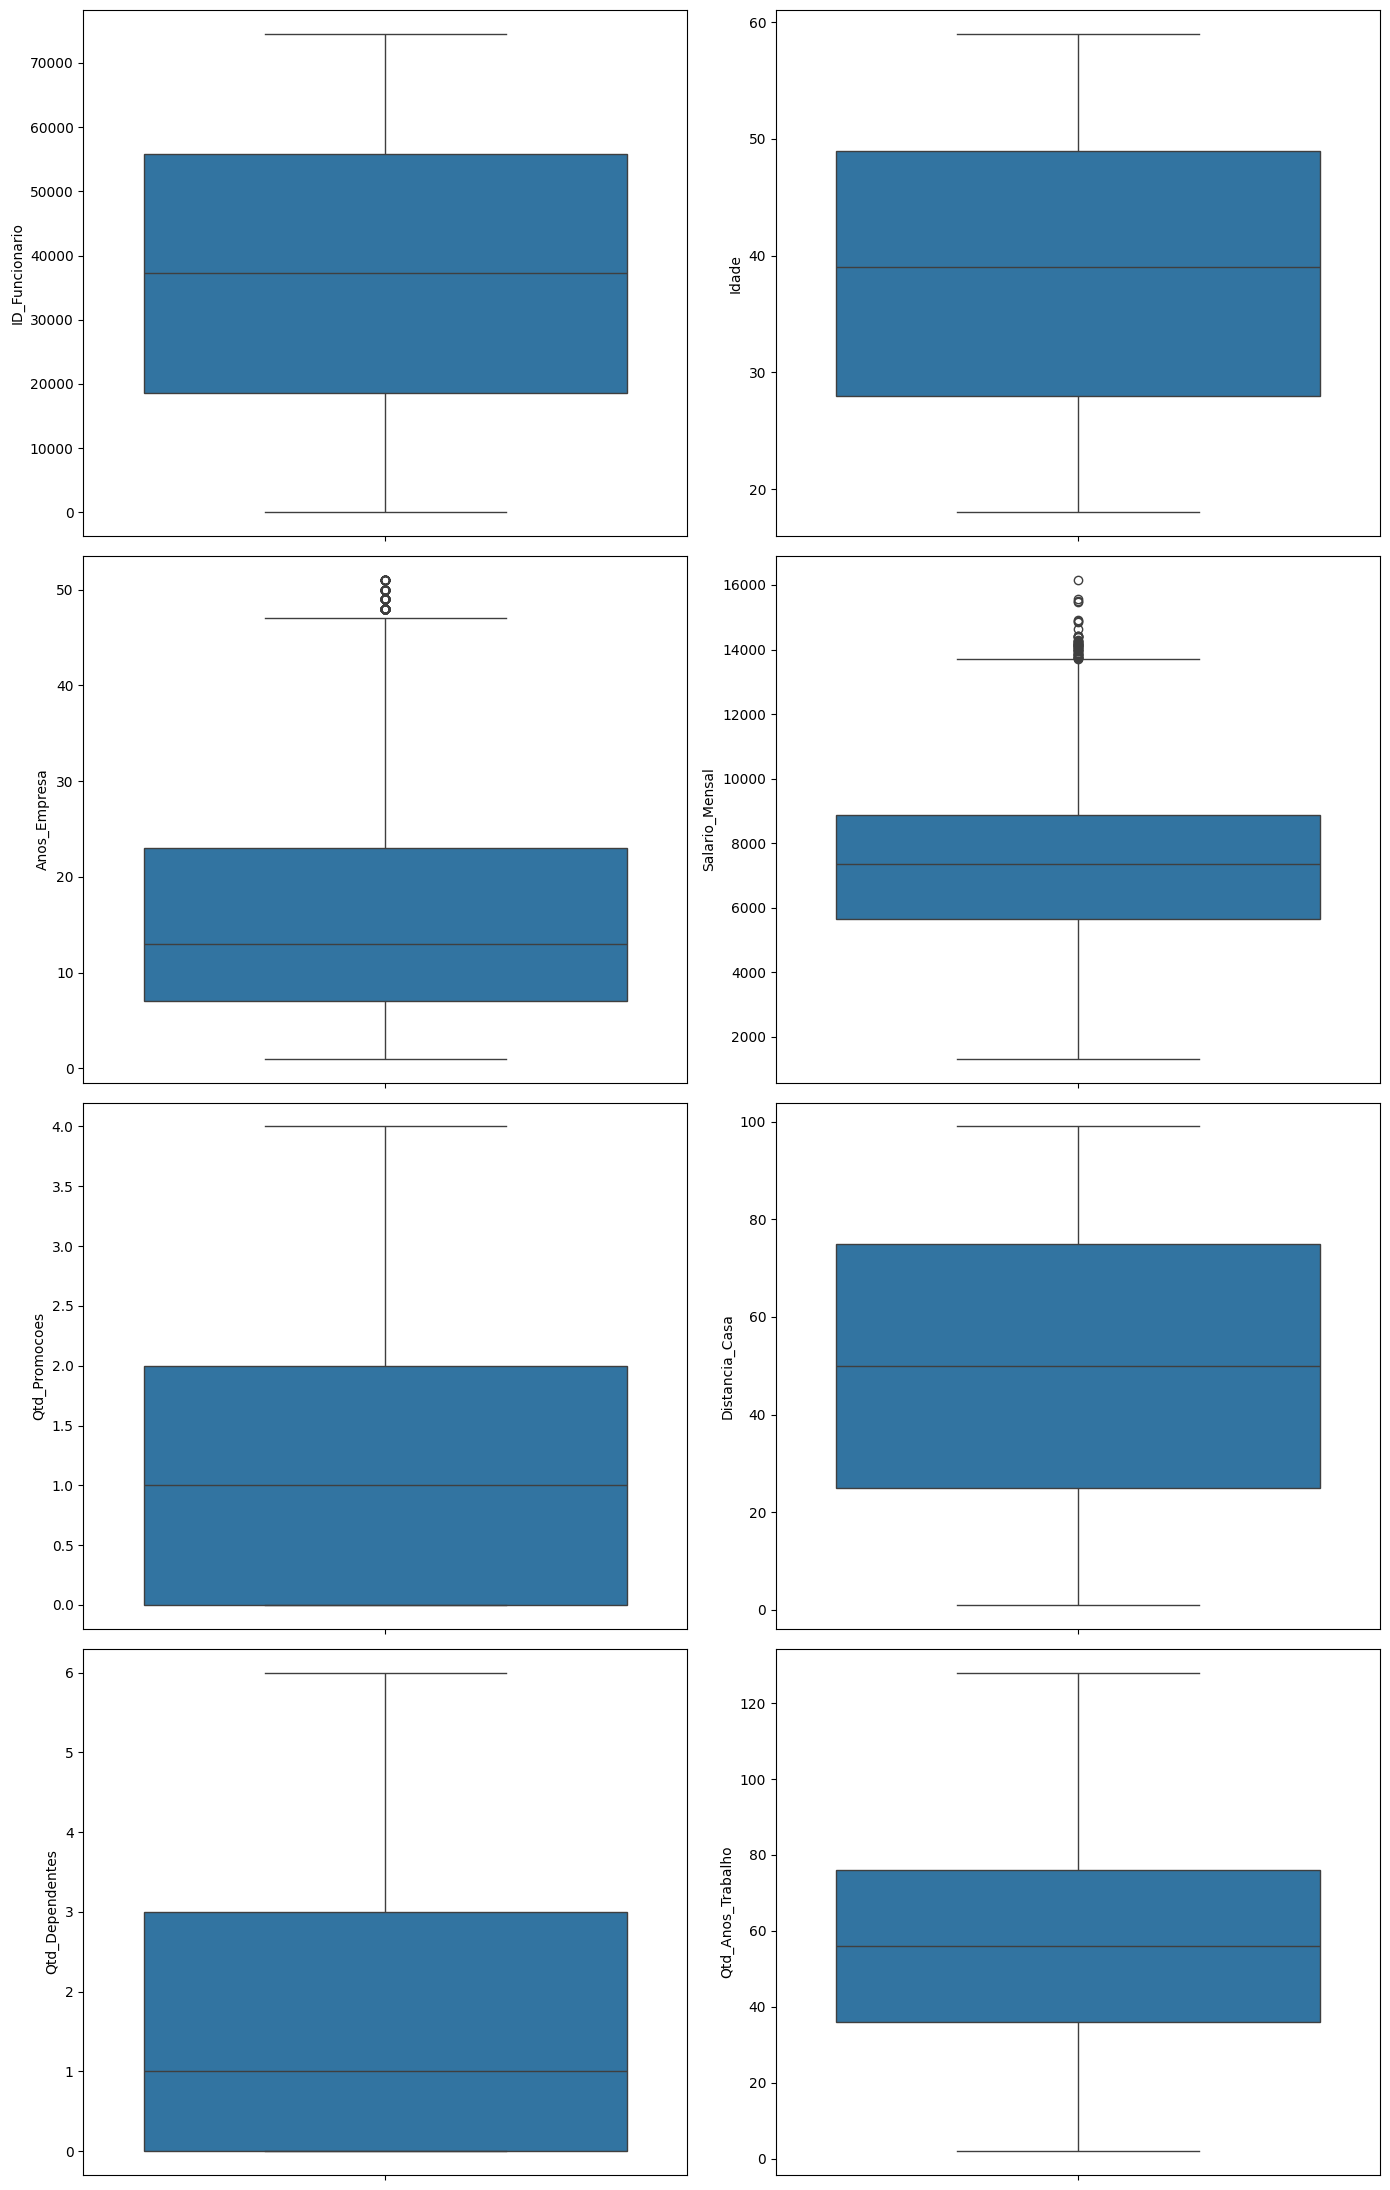

In [78]:
# Vamos analisar os boxplot para podermos avaliar se há "possíveis outliers"

plt.rcParams["figure.figsize"] = [14.00, 22.00]
plt.rcParams["figure.autolayout"] = True
f, axes = plt.subplots(4, 2) #4 linhas e 2 colunas

linha = 0
coluna = 0
for i in variaveis_numericas:
    sns.boxplot(data = df, y=i, ax=axes[linha][coluna])
    coluna += 1
    if coluna == 2:
        linha += 1
        coluna = 0            

plt.show()

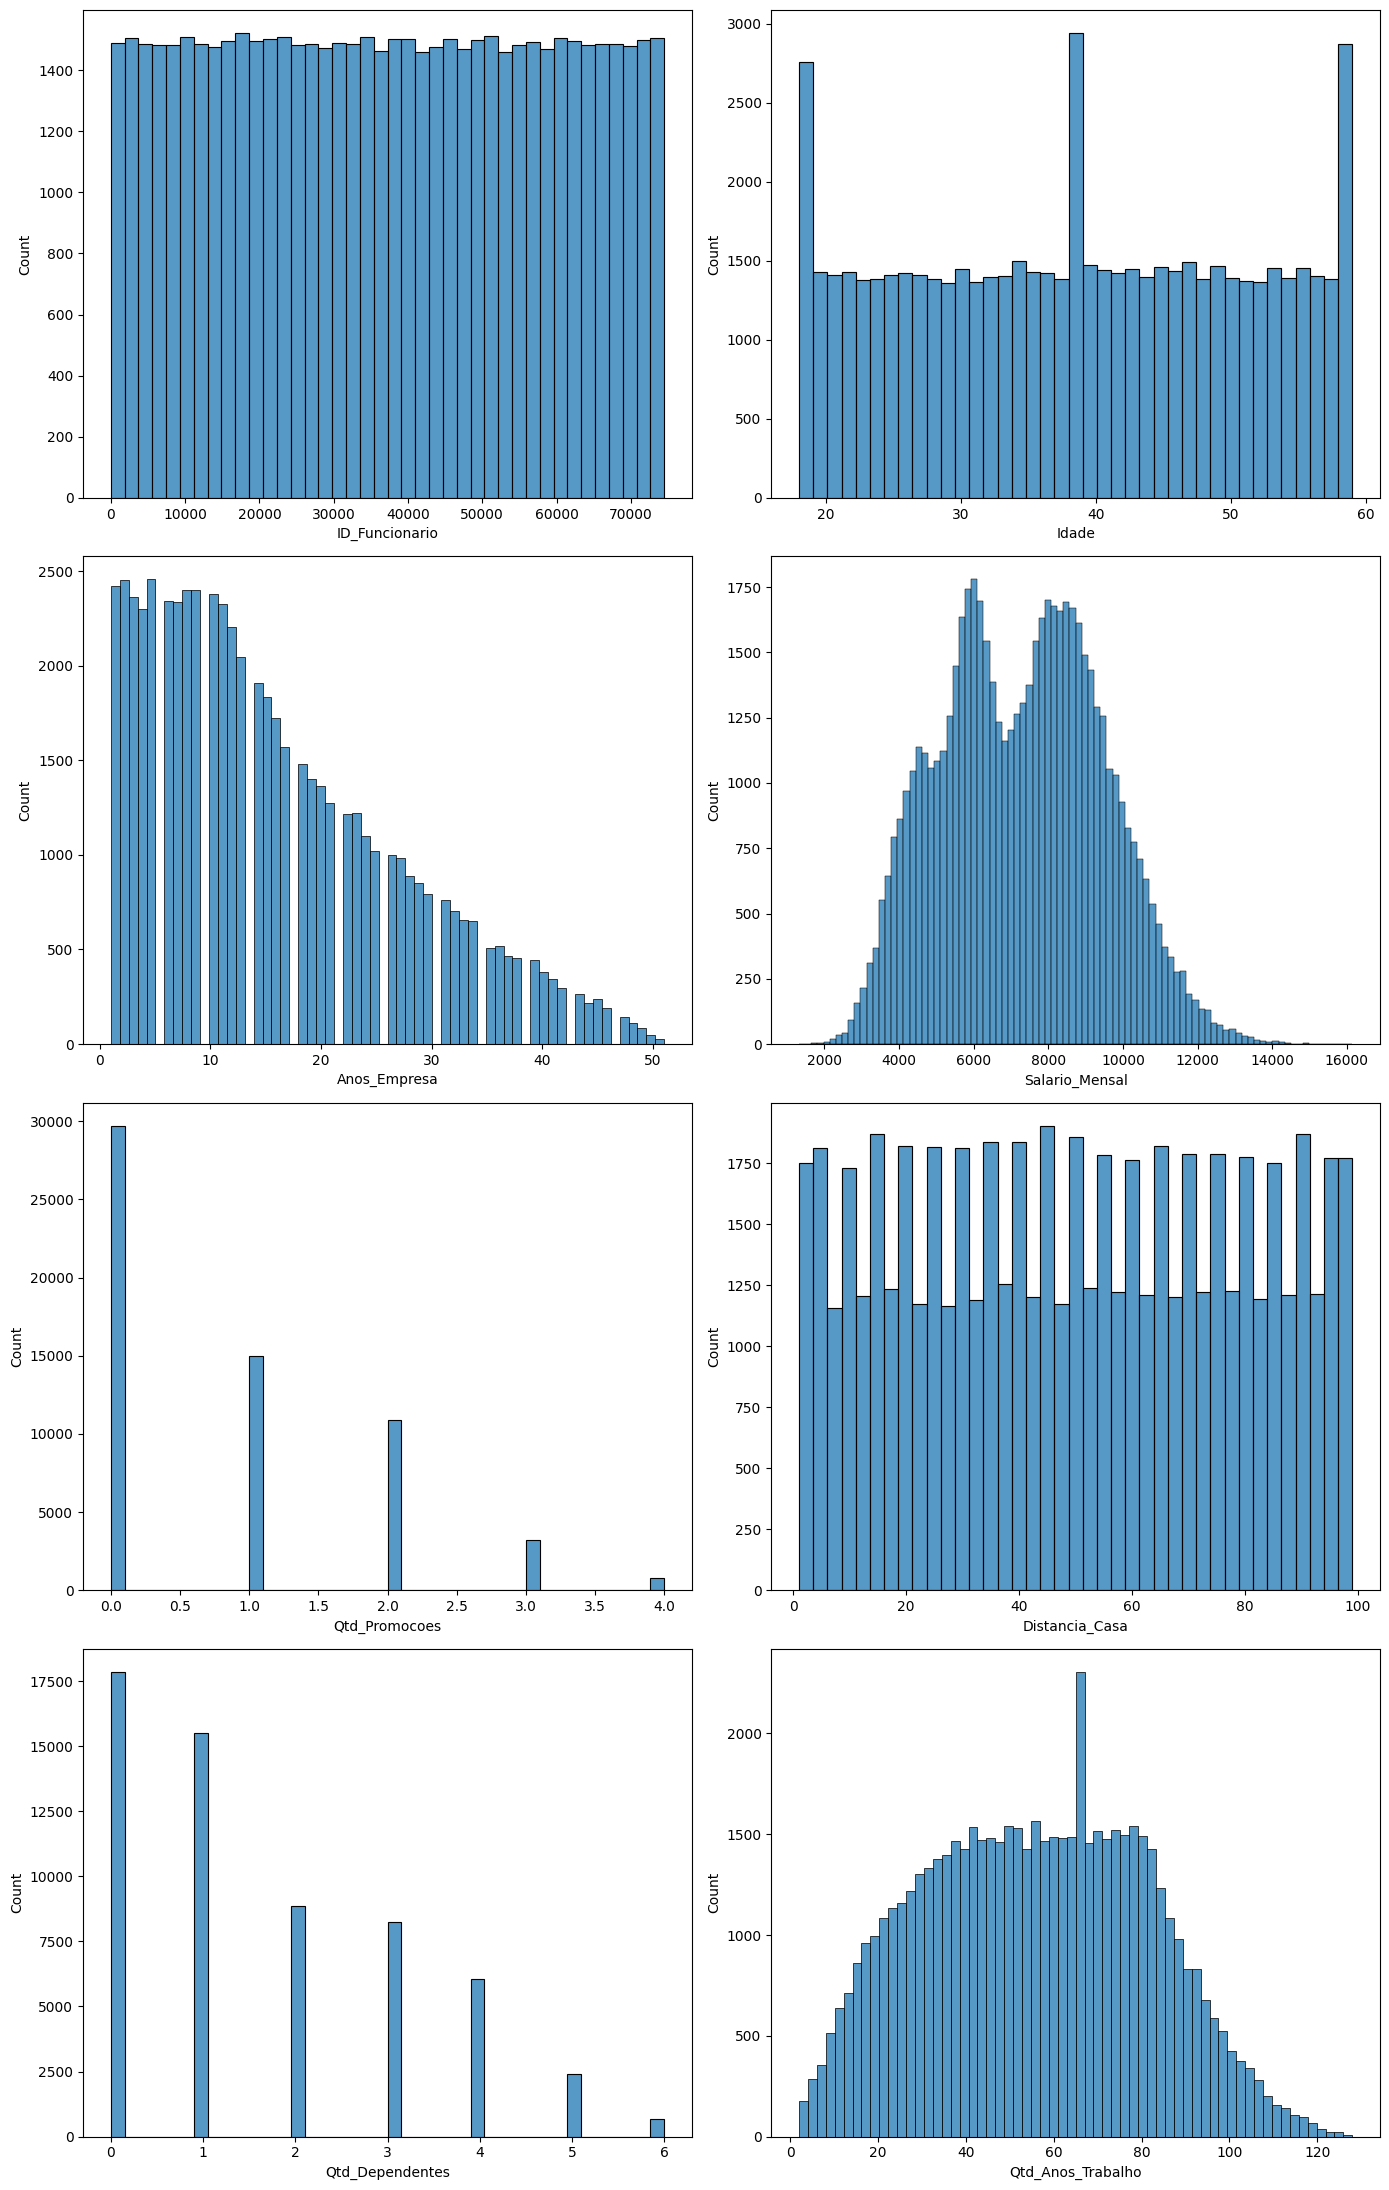

In [79]:
# Vamos avaliar o histograma para analisarmos como os dados estão distribuídos.

plt.rcParams["figure.figsize"] = [14.00, 22.00]
plt.rcParams["figure.autolayout"] = True
f, axes = plt.subplots(4, 2) #4 linhas e 2 colunas

linha = 0
coluna = 0
for i in variaveis_numericas:
    sns.histplot(data = df, x=i, ax=axes[linha][coluna])
    coluna += 1
    if coluna == 2:
        linha += 1
        coluna = 0            

plt.show()

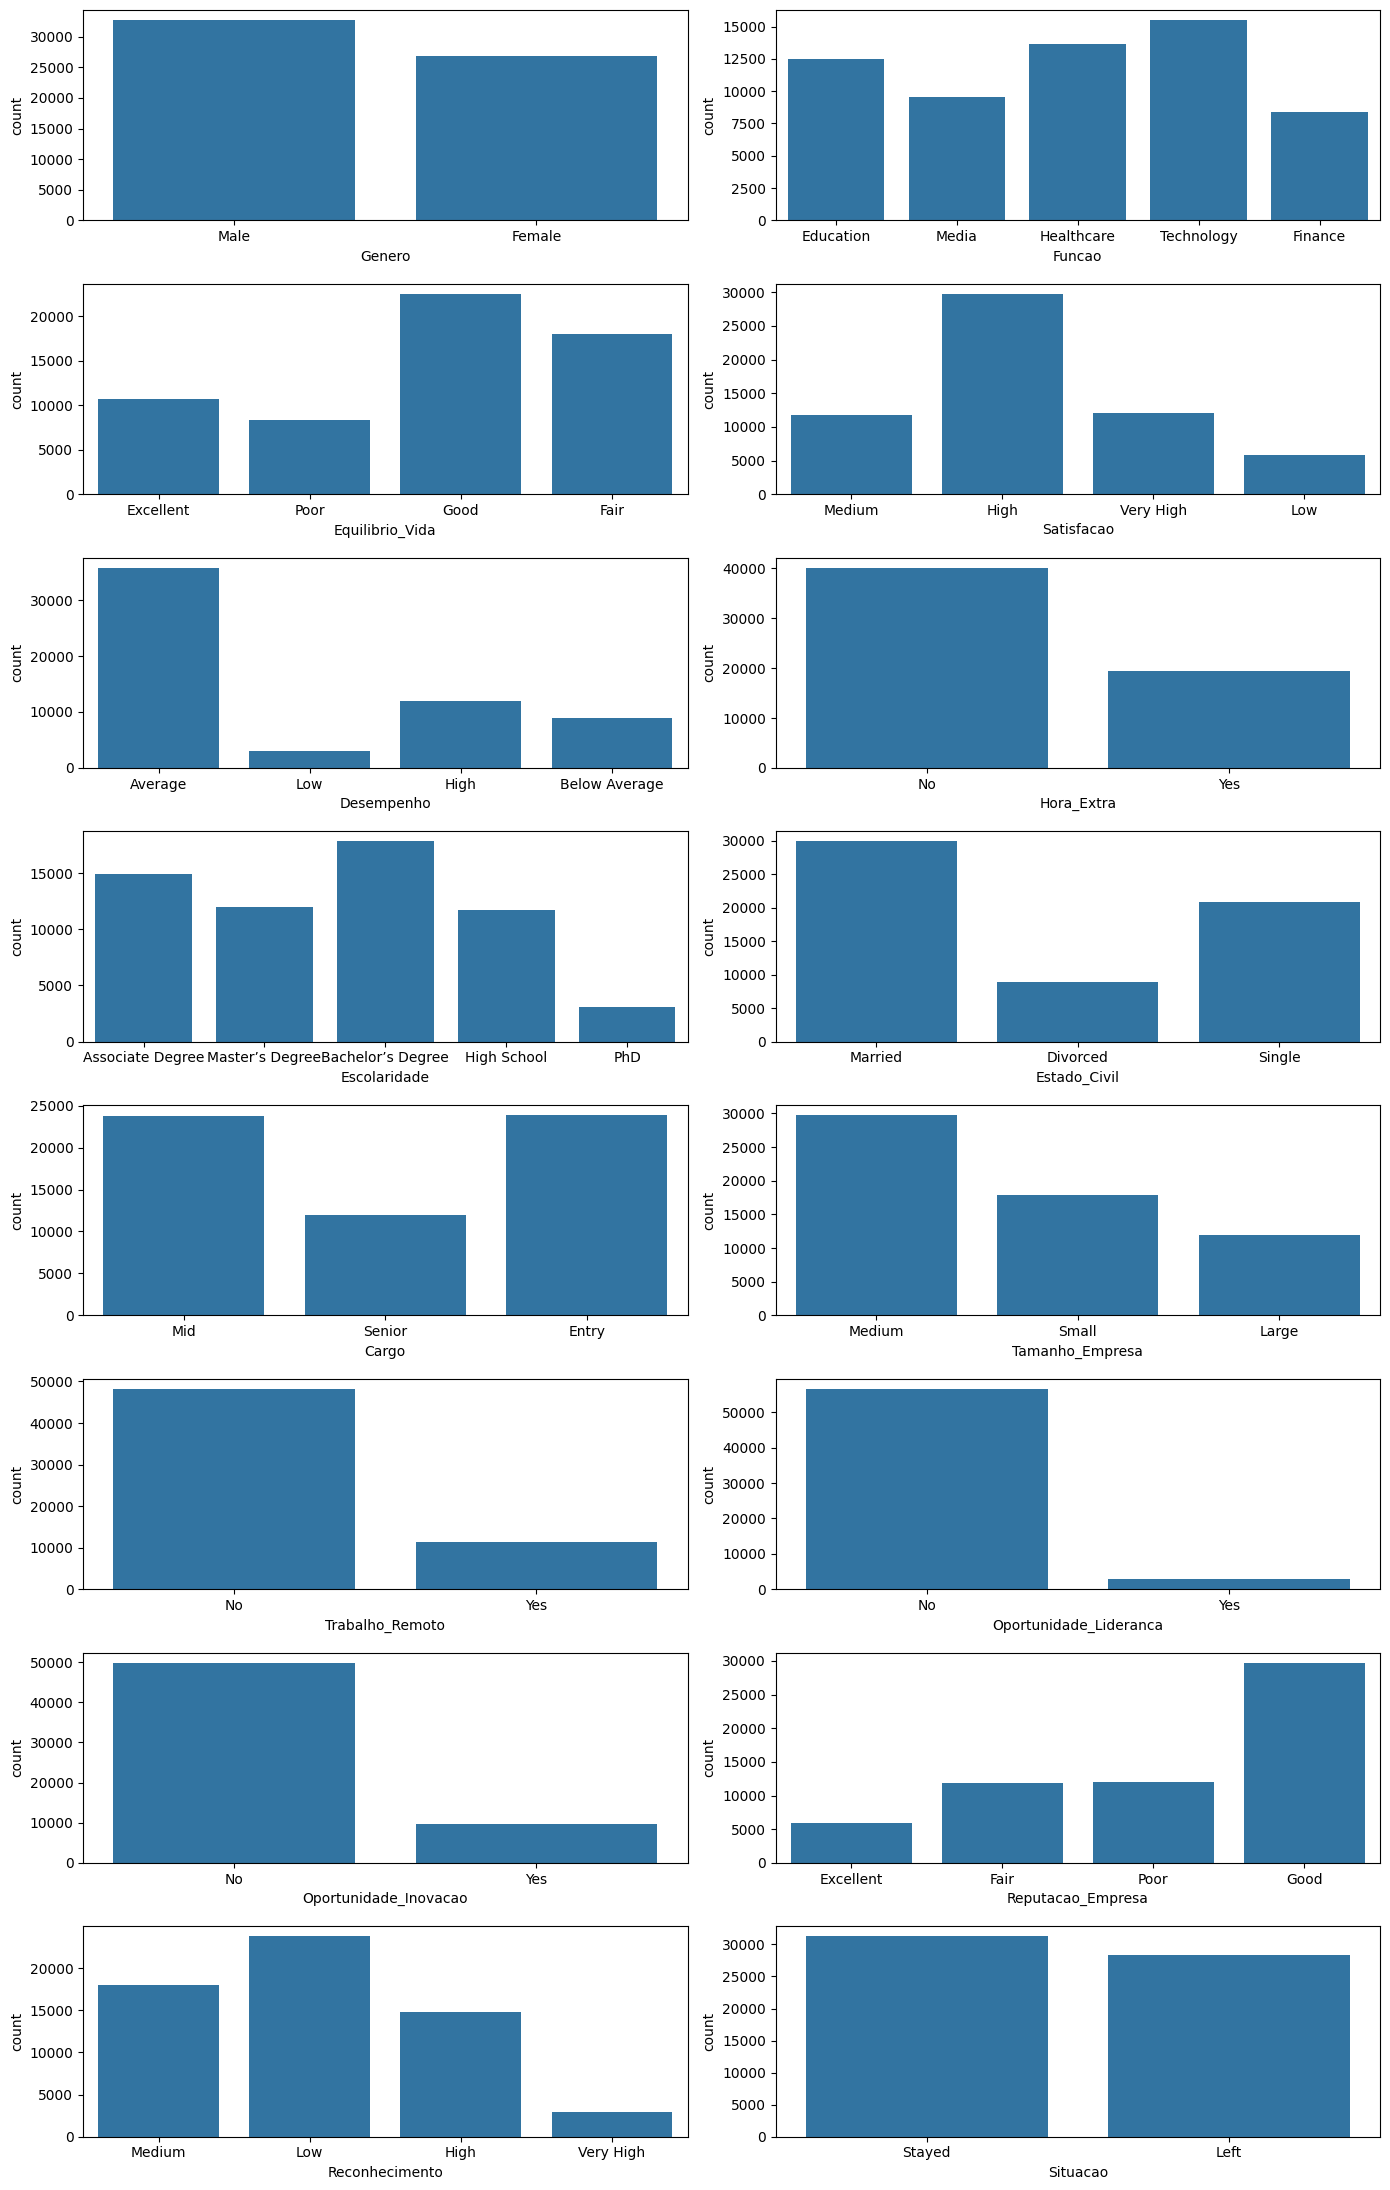

In [80]:
# Vamos analisar as variáveis categóricas para entendermos como os valores estão distribuídos

plt.rcParams["figure.figsize"] = [14.00, 22.00]
plt.rcParams["figure.autolayout"] = True
f, axes = plt.subplots(8, 2) #8 linhas e 2 colunas

linha = 0
coluna = 0
for i in variaveis_categoricas:
    sns.countplot(data = df, x=i, ax=axes[linha][coluna])
    coluna += 1
    if coluna == 2:
        linha += 1
        coluna = 0            

plt.show()

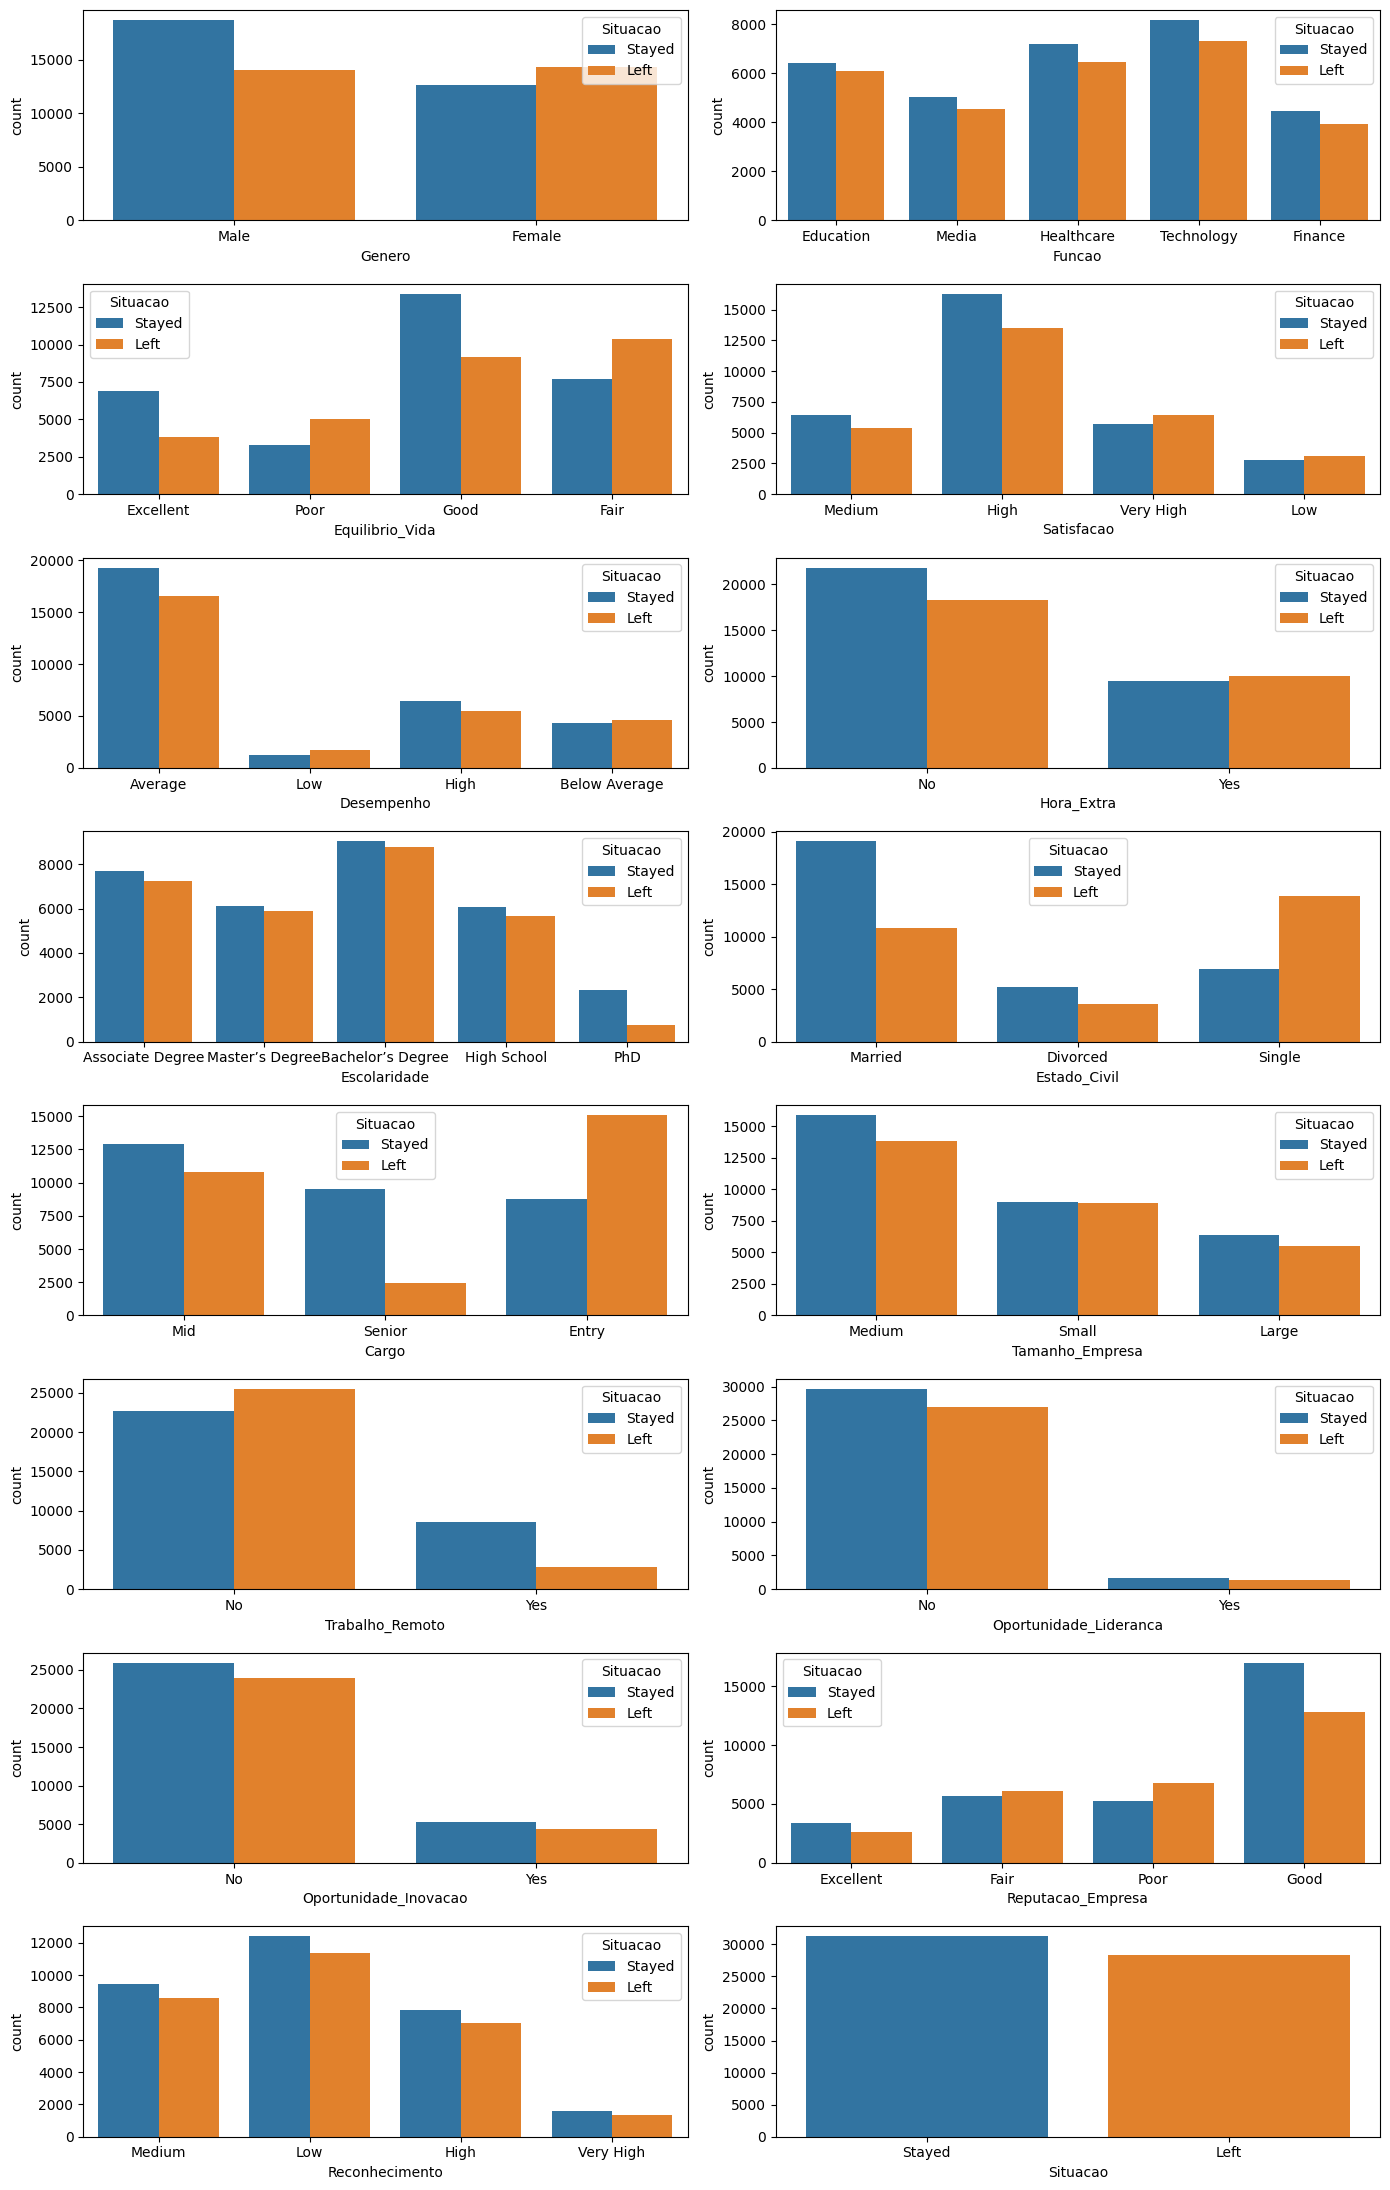

In [81]:
# Vamos analisar as variáveis categóricas para entendermos como os valores estão distribuídos em relação a variável alvo

plt.rcParams["figure.figsize"] = [14.00, 22.00]
plt.rcParams["figure.autolayout"] = True
f, axes = plt.subplots(8, 2) #4 linhas e 2 colunas

linha = 0
coluna = 0
for i in variaveis_categoricas:
    sns.countplot(data = df, x=i, hue = "Situacao", ax=axes[linha][coluna])
    coluna += 1
    if coluna == 2:
        linha += 1
        coluna = 0            

plt.show()

In [82]:
# Validando quantidade de funcionários que ficaram ou saíram

df.groupby(['Situacao']).size()

Situacao
Left      28338
Stayed    31260
dtype: int64

### Pré-Processamento dos dados

Será necessário fazer alguns processo antes de fazer a predição

- Remover variável qtd_anos_trabalho pois está 100% errada
- Remover a variável ID pois ela trata-se apenas da identificação do funcionário
- Preencher os valores nulos de salario_mensal com a mediana dos dados
- Criar uma faixa salarial com base na variável Salario_Mensal
- Corrigir a variável Anos_Empresa cuja subtração da idade for inferior a 18, vamos definir para 1
- A variável Situacao vamos alterar para: 0 = Stayed e 1 = Left
- A variável Situacao será alterada para category
- Vamos fazer o OrdinalEncoder para caregorias ordinais
- Vamos fazer o OneHotEncoder para as variáveis nominais
- Separar as variáveis preditores da variável alvo
- Balancer a nossa variável alvo (Situacao)
- Separar o dados entre treino e teste
- Realizar a normalização dos dados

In [83]:
# Removendo as colunas id e qtd_anos_trabalho

df_corrigido = df.drop(columns=['ID_Funcionario', 'Qtd_Anos_Trabalho'])
df_corrigido.head()

,Idade,Genero,Anos_Empresa,Funcao,Salario_Mensal,Equilibrio_Vida,Satisfacao,Desempenho,Qtd_Promocoes,Hora_Extra,Distancia_Casa,Escolaridade,Estado_Civil,Qtd_Dependentes,Cargo,Tamanho_Empresa,Trabalho_Remoto,Oportunidade_Lideranca,Oportunidade_Inovacao,Reputacao_Empresa,Reconhecimento,Situacao
0,31,Male,19,Education,5390.0,Excellent,Medium,Average,2,No,22,Associate Degree,Married,0,Mid,Medium,No,No,No,Excellent,Medium,Stayed
1,59,Female,4,Media,5534.0,Poor,High,Low,3,No,21,Master’s Degree,Divorced,3,Mid,Medium,No,No,No,Fair,Low,Stayed
2,24,Female,10,Healthcare,8159.0,Good,High,Low,0,No,11,Bachelor’s Degree,Married,3,Mid,Medium,No,No,No,Poor,Low,Stayed
3,36,Female,7,Education,NaN,Good,High,High,1,No,27,High School,Single,2,Mid,Small,Yes,No,No,Good,Medium,Stayed
4,56,Male,41,Education,4821.0,Fair,Very High,Average,0,Yes,71,High School,Divorced,0,Senior,Medium,No,No,No,Fair,Medium,Stayed


In [84]:
# Preenchendo os valores nulos de Salario_Mensal com a mediana

df_corrigido['Salario_Mensal'] = df_corrigido['Salario_Mensal'].fillna(df_corrigido['Salario_Mensal'].median())

In [85]:
# Criando uma faixa salarial com base nos valores

# até 5k
# Entre 5k e 10k
# > 10k

valores = [-100, 5000, 10000, 20000]
rotulos = ['Ate $5.000', 'De $5.001 até $10.000', 'Acima de $10.000']
df_corrigido['Faixa_Salarial'] = pd.cut(df_corrigido['Salario_Mensal'], bins=valores, labels=rotulos)

In [86]:
df_corrigido.head()

,Idade,Genero,Anos_Empresa,Funcao,Salario_Mensal,Equilibrio_Vida,Satisfacao,Desempenho,Qtd_Promocoes,Hora_Extra,Distancia_Casa,Escolaridade,Estado_Civil,Qtd_Dependentes,Cargo,Tamanho_Empresa,Trabalho_Remoto,Oportunidade_Lideranca,Oportunidade_Inovacao,Reputacao_Empresa,Reconhecimento,Situacao,Faixa_Salarial
0,31,Male,19,Education,5390.0,Excellent,Medium,Average,2,No,22,Associate Degree,Married,0,Mid,Medium,No,No,No,Excellent,Medium,Stayed,De $5.001 até $10.000
1,59,Female,4,Media,5534.0,Poor,High,Low,3,No,21,Master’s Degree,Divorced,3,Mid,Medium,No,No,No,Fair,Low,Stayed,De $5.001 até $10.000
2,24,Female,10,Healthcare,8159.0,Good,High,Low,0,No,11,Bachelor’s Degree,Married,3,Mid,Medium,No,No,No,Poor,Low,Stayed,De $5.001 até $10.000
3,36,Female,7,Education,7354.0,Good,High,High,1,No,27,High School,Single,2,Mid,Small,Yes,No,No,Good,Medium,Stayed,De $5.001 até $10.000
4,56,Male,41,Education,4821.0,Fair,Very High,Average,0,Yes,71,High School,Divorced,0,Senior,Medium,No,No,No,Fair,Medium,Stayed,Ate $5.000


In [87]:
# Corrigindo a coluna anos de empresa

df_corrigido.loc[(df_corrigido['Idade'] - df_corrigido['Anos_Empresa'] < 18), 'Anos_Empresa'] = 1

In [88]:
# Alterando a variável Situacao (Variável Alvo)

df_corrigido['Situacao'] = df_corrigido['Situacao'].map({'Stayed':0, 'Left':1})

In [89]:
# Convertendo para variável Situacao para category

df_corrigido['Situacao'] = df_corrigido['Situacao'].astype('category')

In [90]:
# Excluindo a variável Salario_Mensal pois usaremos somente a faixa salarial

df_corrigido.drop(columns=['Salario_Mensal'], inplace=True)
df_corrigido.head()

,Idade,Genero,Anos_Empresa,Funcao,Equilibrio_Vida,Satisfacao,Desempenho,Qtd_Promocoes,Hora_Extra,Distancia_Casa,Escolaridade,Estado_Civil,Qtd_Dependentes,Cargo,Tamanho_Empresa,Trabalho_Remoto,Oportunidade_Lideranca,Oportunidade_Inovacao,Reputacao_Empresa,Reconhecimento,Situacao,Faixa_Salarial
0,31,Male,1,Education,Excellent,Medium,Average,2,No,22,Associate Degree,Married,0,Mid,Medium,No,No,No,Excellent,Medium,0,De $5.001 até $10.000
1,59,Female,4,Media,Poor,High,Low,3,No,21,Master’s Degree,Divorced,3,Mid,Medium,No,No,No,Fair,Low,0,De $5.001 até $10.000
2,24,Female,1,Healthcare,Good,High,Low,0,No,11,Bachelor’s Degree,Married,3,Mid,Medium,No,No,No,Poor,Low,0,De $5.001 até $10.000
3,36,Female,7,Education,Good,High,High,1,No,27,High School,Single,2,Mid,Small,Yes,No,No,Good,Medium,0,De $5.001 até $10.000
4,56,Male,1,Education,Fair,Very High,Average,0,Yes,71,High School,Divorced,0,Senior,Medium,No,No,No,Fair,Medium,0,Ate $5.000


In [91]:
# Carregando as variáveis categóricas ordinais

variaveis_categoricas_ordinais = ['Faixa_Salarial','Equilibrio_Vida','Satisfacao','Desempenho','Escolaridade','Cargo', 'Tamanho_Empresa','Reputacao_Empresa','Reconhecimento']

In [92]:
# Convertendo para o ordinal_encoder

encoder = OrdinalEncoder()

for var in variaveis_categoricas_ordinais:
    df_corrigido[var] = encoder.fit_transform(df_corrigido[var])


In [94]:
df_corrigido.head()

,Idade,Genero,Anos_Empresa,Funcao,Equilibrio_Vida,Satisfacao,Desempenho,Qtd_Promocoes,Hora_Extra,Distancia_Casa,Escolaridade,Estado_Civil,Qtd_Dependentes,Cargo,Tamanho_Empresa,Trabalho_Remoto,Oportunidade_Lideranca,Oportunidade_Inovacao,Reputacao_Empresa,Reconhecimento,Situacao,Faixa_Salarial
0,31,Male,1,Education,1,1,1,2,No,22,1,Married,0,1,1,No,No,No,1,1,0,2
1,59,Female,4,Media,2,2,2,3,No,21,2,Divorced,3,1,1,No,No,No,2,2,0,2
2,24,Female,1,Healthcare,3,2,2,0,No,11,3,Married,3,1,1,No,No,No,3,2,0,2
3,36,Female,7,Education,3,2,3,1,No,27,4,Single,2,1,2,Yes,No,No,4,1,0,2
4,56,Male,1,Education,4,3,1,0,Yes,71,4,Divorced,0,2,1,No,No,No,2,1,0,1


In [95]:
# Carregando as variáveis categoricas nominais (OneHotEncoding)

variaveis_categoricas_nominais = ['Genero','Funcao','Hora_Extra','Estado_Civil','Trabalho_Remoto','Oportunidade_Lideranca', 'Oportunidade_Inovacao']

In [96]:
# Aplicando o onehotencoding

encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(df_corrigido[variaveis_categoricas_nominais])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(variaveis_categoricas_nominais))
df_coded = pd.concat([df_corrigido, one_hot_df], axis=1)
df_coded = df_coded.drop(variaveis_categoricas_nominais, axis=1) 

In [97]:
df_coded.head()

,Idade,Anos_Empresa,Equilibrio_Vida,Satisfacao,Desempenho,Qtd_Promocoes,Distancia_Casa,Escolaridade,Qtd_Dependentes,Cargo,Tamanho_Empresa,Reputacao_Empresa,Reconhecimento,Situacao,Faixa_Salarial,Genero_Female,Genero_Male,Funcao_Education,Funcao_Finance,Funcao_Healthcare,Funcao_Media,Funcao_Technology,Hora_Extra_No,Hora_Extra_Yes,Estado_Civil_Divorced,Estado_Civil_Married,Estado_Civil_Single,Trabalho_Remoto_No,Trabalho_Remoto_Yes,Oportunidade_Lideranca_No,Oportunidade_Lideranca_Yes,Oportunidade_Inovacao_No,Oportunidade_Inovacao_Yes
0,31,1,1,1,1,2,22,1,0,1,1,1,1,0,2,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,59,4,2,2,2,3,21,2,3,1,1,2,2,0,2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,24,1,3,2,2,0,11,3,3,1,1,3,2,0,2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,36,7,3,2,3,1,27,4,2,1,2,4,1,0,2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
4,56,1,4,3,1,0,71,4,0,2,1,2,1,0,1,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [98]:
# Separando entre preditoras e alvo

preditora = df_coded.drop(['Situacao'], axis=1)
target = df_coded['Situacao'].copy()

In [99]:
# Balanceando os dados

balanceador = RandomUnderSampler(random_state=42, sampling_strategy='majority')

In [100]:
# Aplicando o balanceador

preditora_bal, target_bal = balanceador.fit_resample(preditora, target)

In [103]:
# Validar se o balanceamento foi bem feito

print(target_bal.value_counts())

Situacao
0    28338
1    28338
Name: count, dtype: int64


In [104]:
# Separando em treino e teste

x_treino, x_teste, y_treino, y_teste = train_test_split(preditora_bal, target_bal, test_size=0.3, random_state=42)

In [105]:
# Normalizando os dados

normalizador = MinMaxScaler()

In [106]:
# Aplicando nos dados de treino e teste

x_treino_normalizado = normalizador.fit_transform(x_treino)

x_teste_normalizado = normalizador.transform(x_teste)

### Aplicando os algoritmos e validando qual será escolhido

vamos testar 3 algoritmos e escolher entre 1 deles

#### KNN

In [107]:
# Contrução do modelo

knn = KNeighborsClassifier()

In [108]:
# Treinando o modelo

knn = knn.fit(x_treino_normalizado, y_treino)

In [ ]:
# Previsao e Acuracia - Treino

previsao = knn.predict(x_treino_normalizado)
accuracy_score(previsao, y_treino)

0.7719859854308976

In [110]:
# Previsao e Acuracia - Treino

previsao = knn.predict(x_teste_normalizado)
accuracy_score(previsao, y_teste)

0.6567076398282656

#### SVM

In [111]:
# Contrução do modelo

svm = SVC()

In [112]:
# Treinando o modelo

svm = svm.fit(x_treino_normalizado, y_treino)

In [113]:
# Previsao e Acuracia - Treino

previsao = svm.predict(x_treino_normalizado)
accuracy_score(previsao, y_treino)

0.7436291684520959

In [114]:
# Previsao e Acuracia - Treino

previsao = svm.predict(x_teste_normalizado)
accuracy_score(previsao, y_teste)

0.7251661471505029

#### Random Forest

In [115]:
# Contrução do modelo

clf = RandomForestClassifier()

In [116]:
# Treinando o modelo

clf = clf.fit(x_treino_normalizado, y_treino)

In [117]:
# Previsao e Acuracia - Treino

previsao = clf.predict(x_treino_normalizado)
accuracy_score(previsao, y_treino)

1.0

In [118]:
# Previsao e Acuracia - Treino

previsao = clf.predict(x_teste_normalizado)
accuracy_score(previsao, y_teste)

0.7419278950773393